<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Meta%20Platforms%20META%20Stock%20Price%20History%202012%202026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Meta Platforms META Stock Price History 2012-2026

## Understanding Meta Platforms (META) Stock: A Deep Dive into its History and Dynamics (2012-2026)

This analysis delved into the historical stock price data for Meta Platforms (formerly Facebook), covering a period from its IPO in 2012 up to early 2026. The dataset provides a comprehensive look at the company's daily Open, High, Low, Close prices, and Volume of shares traded. A thorough initial inspection confirmed the data's cleanliness, revealing no missing values or duplicates, which is an excellent foundation for reliable analysis.

Our journey began by exploring individual features. As expected for a growth stock, META's prices generally demonstrated a significant upward trend over the years, though punctuated by periods of considerable volatility. Trading Volume showed typical patterns: high spikes around its IPO and during major price movements, indicating significant market activity during key events.

Moving to multi-variate relationships, we observed strong positive correlations between the various price metrics (Open, High, Low, Close), a standard characteristic of stock data where these values move in tandem throughout a trading day. By grouping the data by Year, we could clearly visualize the long-term growth trajectory of META's valuation, revealing how its average price has evolved annually. However, this also highlighted years of significant downturns, such as 2022, reminding us that even strong growth stories face market corrections.

The statistical analysis offered crucial insights into the intrinsic nature of META's stock. We found that while the raw stock prices themselves are non-stationary (meaning their statistical properties like mean and variance change over time, indicating a trend), the Daily Returns (percentage change in price) are indeed stationary. This is a vital discovery for time-series modeling, as stationary data is a prerequisite for many predictive algorithms.

Perhaps one of the most profound findings relates to the normality of returns. META's daily returns were definitively not normally distributed; instead, they exhibited what statisticians call 'Fat Tails'. In human terms, this means that extreme price movements—both large gains and significant losses—occur far more frequently than a standard bell curve (normal distribution) would predict. This phenomenon, often associated with 'Black Swan' events, underscores the inherent unpredictability and risk of stock markets. Our calculation of the 95% Value at Risk (VaR) further quantified this risk, estimating the maximum expected daily loss at a 95% confidence level.

To prepare for potential predictive modeling, we engineered a suite of financial technical indicators. These included various Simple Moving Averages (SMAs), Exponential Moving Averages (EMAs), the Relative Strength Index (RSI), MACD, and Bollinger Bands. These indicators are designed to capture trends, momentum, and volatility, providing richer features for a machine learning model.

Finally, we built a Random Forest Classifier to predict the stock's direction (Up or Down) for the next day. The model's performance, with an accuracy of around 48%, indicated it performed slightly worse than a random guess (a coin flip). The backtest further solidified this, showing that the AI trading strategy underperformed a simple

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d omarshahrukh/meta-platforms-meta-stock-price-history-2012-2026

# Unziping the downloaded file
!unzip meta-platforms-meta-stock-price-history-2012-2026.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/omarshahrukh/meta-platforms-meta-stock-price-history-2012-2026
License(s): CC-BY-NC-SA-4.0
  0% 0.00/57.2k [00:00<?, ?B/s]
100% 57.2k/57.2k [00:00<00:00, 159MB/s]
Archive:  meta-platforms-meta-stock-price-history-2012-2026.zip
  inflating: meta_stock_data.csv     


# Data Inspection

In [3]:
df = pd.read_csv('meta_stock_data.csv')
df.head(11)

,Date,Open,High,Low,Close,Volume
0,2012-05-18,41.76,44.69,37.74,37.96,573576400
1,2012-05-21,36.28,36.41,32.77,33.79,168192700
2,2012-05-22,32.38,33.36,30.73,30.78,101786600
3,2012-05-23,31.15,32.27,31.14,31.78,73600000
4,2012-05-24,32.72,32.98,31.55,32.80,50237200
5,2012-05-25,32.67,32.72,30.89,31.69,37149800
6,2012-05-29,31.26,31.47,28.45,28.64,78063400
7,2012-05-30,28.50,29.35,27.67,27.99,57267900
8,2012-05-31,28.35,29.46,26.64,29.39,111639200
9,2012-06-01,28.69,28.95,27.20,27.53,41855500


In [4]:
df.tail(11)

,Date,Open,High,Low,Close,Volume
3444,2026-01-30,727.50,732.17,713.59,716.50,23744600
3445,2026-02-02,714.60,721.30,703.52,706.41,14365200
3446,2026-02-03,707.37,717.00,686.41,691.70,13760700
3447,2026-02-04,687.73,688.83,667.46,668.99,16882800
3448,2026-02-05,663.58,681.50,653.50,670.21,17131800
3449,2026-02-06,665.49,671.99,646.50,661.46,18159300
3450,2026-02-09,663.18,683.31,658.78,677.22,14837500
3451,2026-02-10,677.60,680.65,669.79,670.72,10455800
3452,2026-02-11,674.00,679.27,657.10,668.69,14323800
3453,2026-02-12,669.97,676.00,645.28,649.81,14960100


In [5]:
df.shape

(3455, 6)

In [6]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [7]:
df.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3455 entries, 0 to 3454
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3455 non-null   object 
 1   Open    3455 non-null   float64
 2   High    3455 non-null   float64
 3   Low     3455 non-null   float64
 4   Close   3455 non-null   float64
 5   Volume  3455 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 162.1+ KB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,3455,3455,2026-02-13,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Open,3455.0,NaN,NaN,NaN,223.520414,182.212248,17.95,95.8,172.25,292.175,789.97
High,3455.0,NaN,NaN,NaN,226.340744,184.304224,18.14,96.995,174.16,296.05,795.06
Low,3455.0,NaN,NaN,NaN,220.634084,179.794139,17.43,94.14,170.24,286.455,779.66
Close,3455.0,NaN,NaN,NaN,223.522292,182.025729,17.61,95.785,172.01,291.84,788.82
Volume,3455.0,NaN,NaN,NaN,28233568.248915,25116150.099179,4726100.0,14779150.0,20894100.0,32043050.0,573576400.0


In [10]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


In [11]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

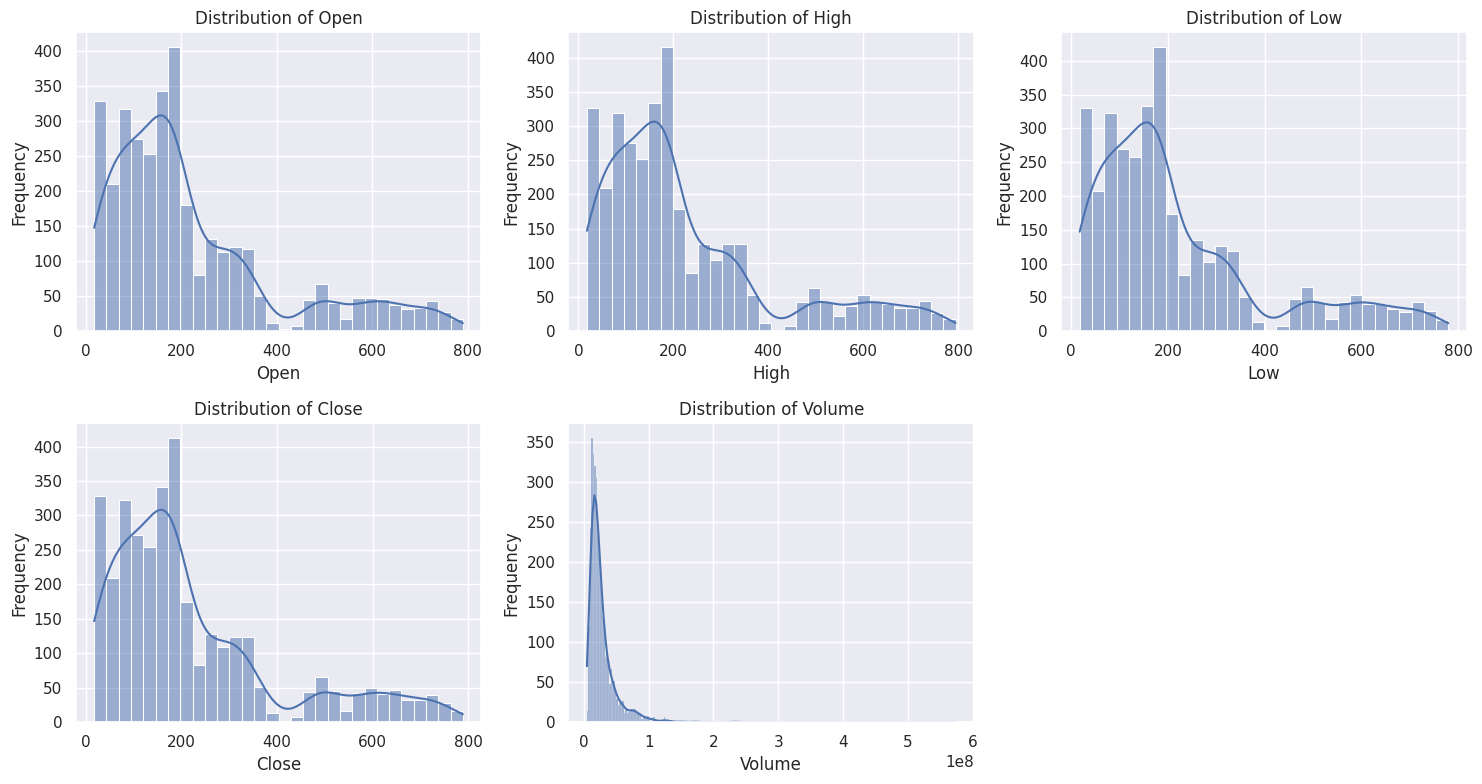

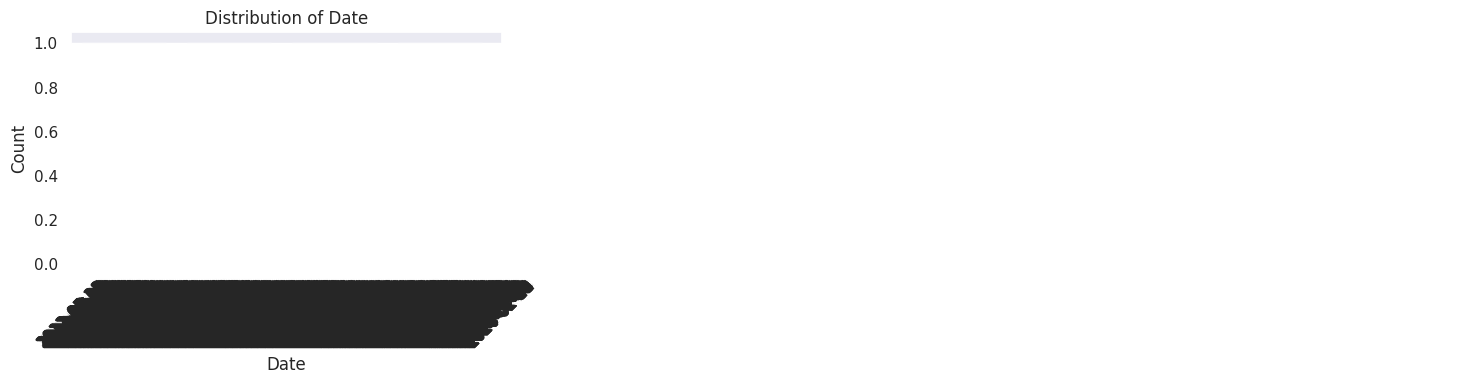

--- Categorical Value Counts ---

Value counts for Date:
Date
2026-02-13    1
2012-05-18    1
2012-05-21    1
2012-05-22    1
2012-05-23    1
             ..
2012-06-15    1
2012-06-14    1
2012-06-13    1
2012-06-12    1
2012-06-11    1
Name: count, Length: 3455, dtype: int64


In [12]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Define grid size
    num_plots = len(numerical_cols)
    num_cols = 3  # You can change this to 2 or 4 if preferred
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()  # Flatten to 1D array for easy iteration

    # Iterate and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hidding any unused subplots (if total plots < grid cells)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
categorical_cols = df.select_dtypes(include='object').columns.tolist()

if len(categorical_cols) > 0:
    # Define grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterate and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found.")

# Bivariate Analysis

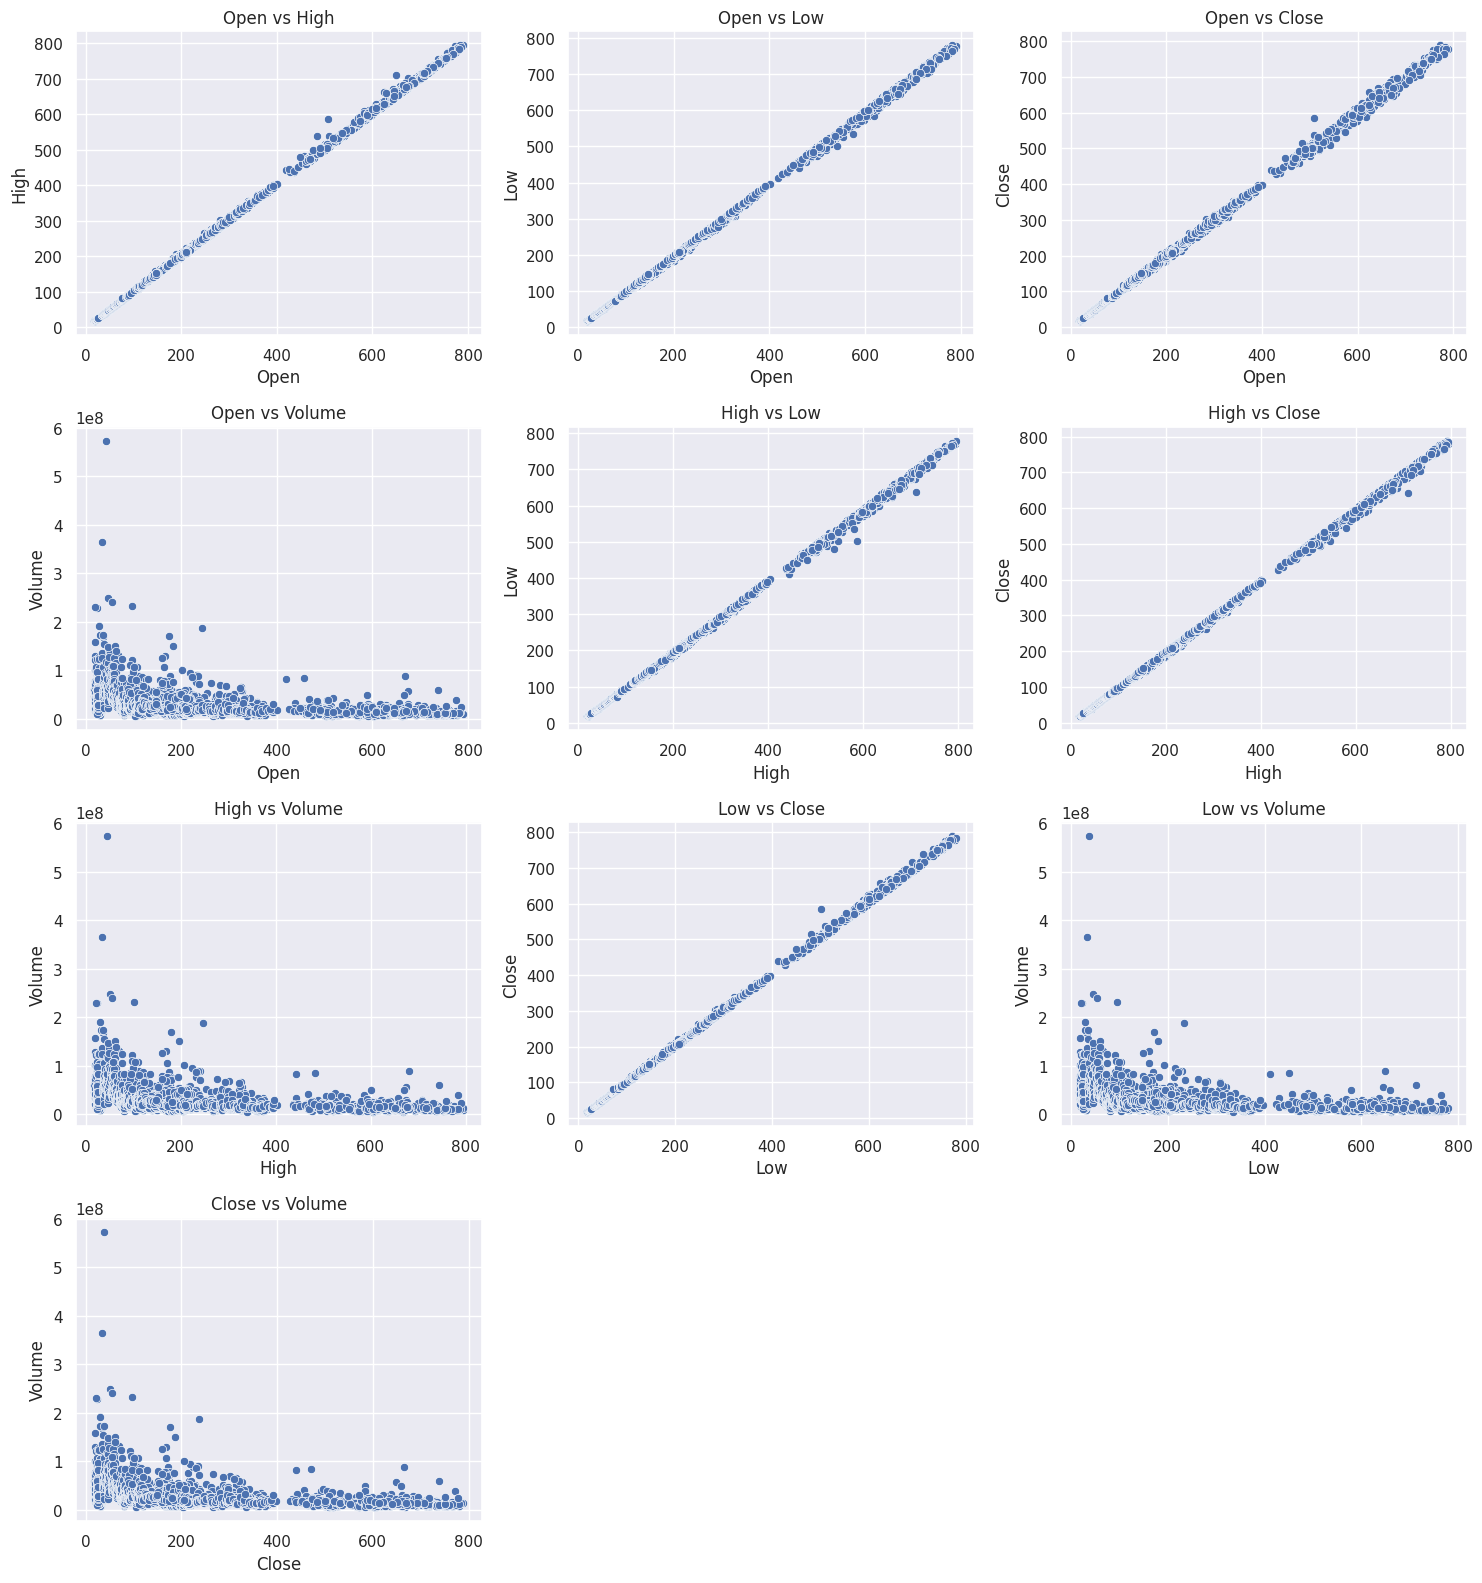

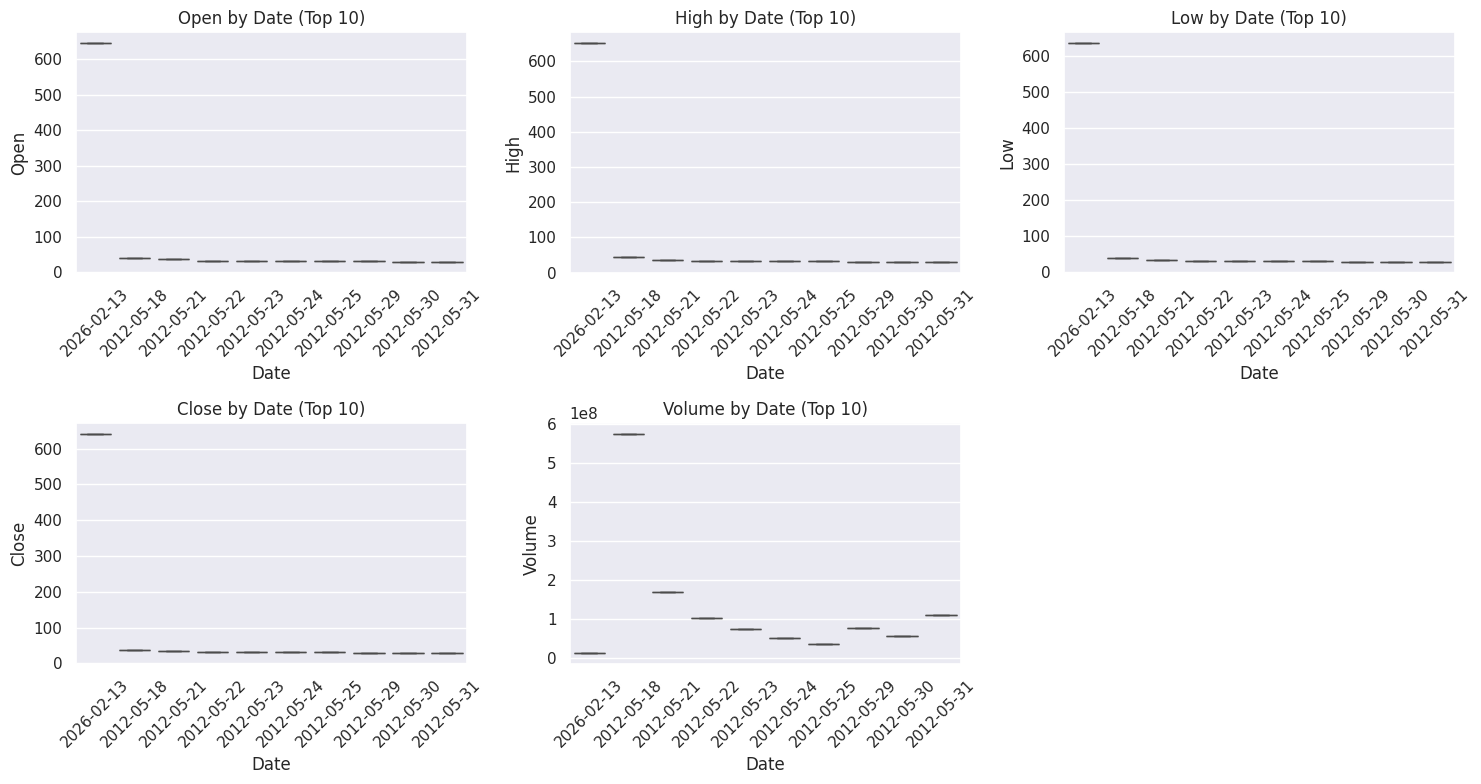

In [13]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generate all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Define grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Flatten axes for easy iteration.
    # Handle edge case where there is only 1 plot (axes is not an array)
    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterate through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generate all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Define grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterate through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        # 1. Get top 10 categories based on frequency
        top_categories = df[cat_col].value_counts().nlargest(10).index.tolist()

        # 2. Filter data: Keep only top categories AND ensure numerical column is not NaN
        filtered_df = df[df[cat_col].isin(top_categories) & df[num_col].notnull()]

        # 3. Update 'order' to only include categories that exist in the filtered data
        # This prevents the ValueError where a category in 'order' has no data to plot
        valid_categories = [cat for cat in top_categories if cat in filtered_df[cat_col].unique()]

        if valid_categories:
            sns.boxplot(data=filtered_df, x=cat_col, y=num_col, ax=axes[i], order=valid_categories)
            axes[i].set_title(f'{num_col} by {cat_col} (Top 10)')
            axes[i].set_xlabel(cat_col)
            axes[i].set_ylabel(num_col)
            axes[i].tick_params(axis='x', rotation=45)
        else:
             axes[i].text(0.5, 0.5, "No valid data", ha='center', va='center')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")

# Multivariate Analysis

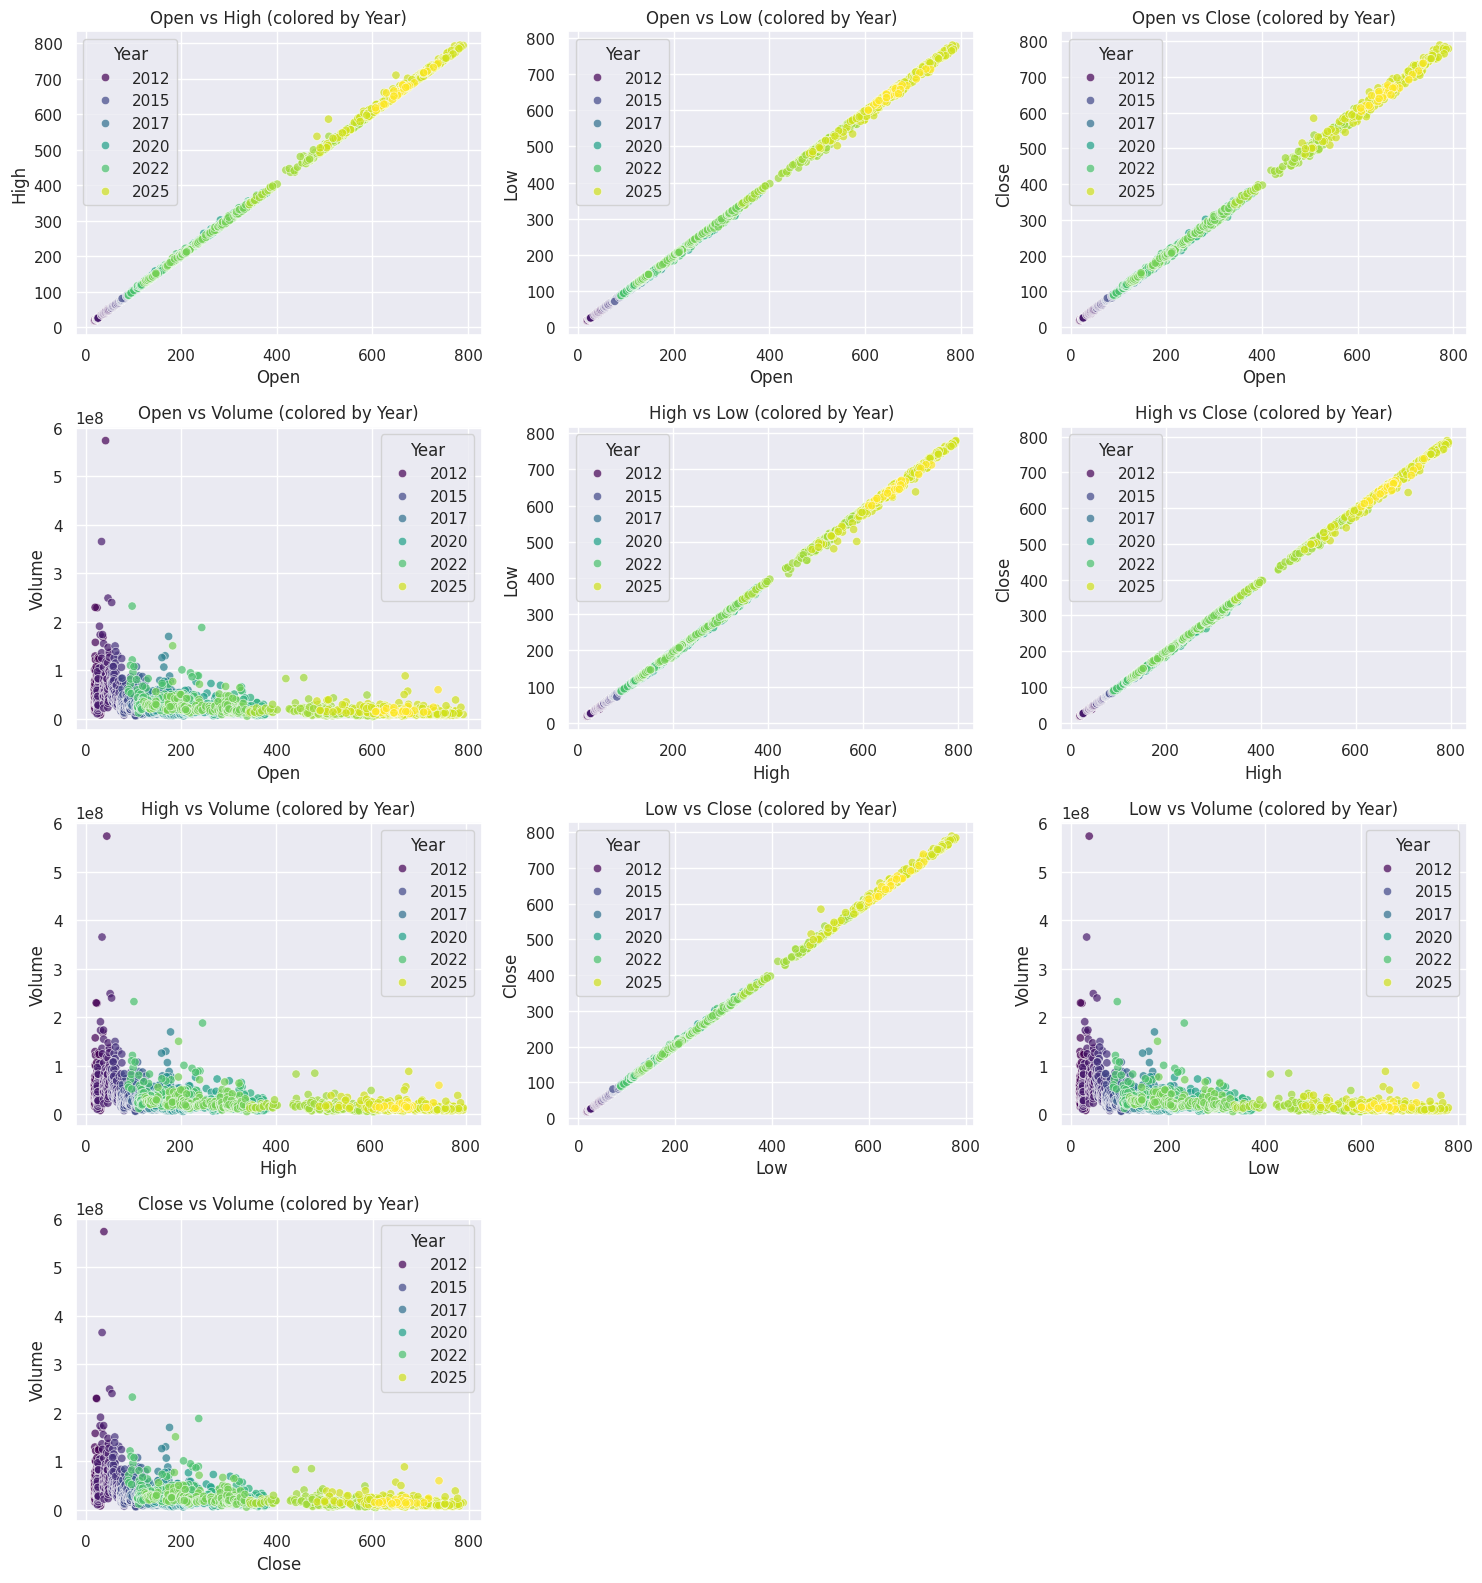


--- Multivariate Summary by 'Year' ---
Displaying mean values of numerical features for each 'Year':



,Open,High,Low,Close,Volume
Year,,,,,
2012,24.627613,25.125290,24.027871,24.502000,5.464815e+07
2013,35.230198,35.795040,34.687937,35.235040,6.009199e+07
2014,68.287024,69.156627,67.359643,68.285040,4.753055e+07
2015,88.133929,89.061310,87.153968,88.157143,2.695888e+07
2016,116.268730,117.271905,115.062103,116.223929,2.547507e+07
2017,155.395817,156.464701,154.269761,155.490040,1.678995e+07
2018,170.283665,172.408765,168.128645,170.320916,2.765860e+07
2019,180.307103,182.209881,178.402579,180.377659,1.620627e+07
2020,232.723281,236.289209,229.188972,232.923676,2.244630e+07


In [17]:
import itertools
import math

# --- Pre-processing: Extract Year for better categorization ---
if df['Date'].dtype == 'object':
    df['Date'] = pd.to_datetime(df['Date'])

# Creating a Year column to use as a meaningful categorical variable
df['Year'] = df['Date'].dt.year

# --- 1. Multivariate Scatter Plots (Grid with Hue: Year) ---

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Removing 'Year' from numerical_cols if it got added there, as we use it for hue
if 'Year' in numerical_cols:
    numerical_cols.remove('Year')

hue_col = 'Year'

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iteratting and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, hue=hue_col, ax=axes[i], alpha=0.7, palette='viridis')
        axes[i].set_title(f'{col1} vs {col2} (colored by {hue_col})')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for multivariate scatter plots.")


# --- 2. Multivariate Summary (Grouped by Year) ---

print(f"\n--- Multivariate Summary by '{hue_col}' ---")
print(f"Displaying mean values of numerical features for each '{hue_col}':\n")

# Grouping by Year and calculate mean
year_summary = df.groupby(hue_col)[numerical_cols].mean()
display(year_summary)

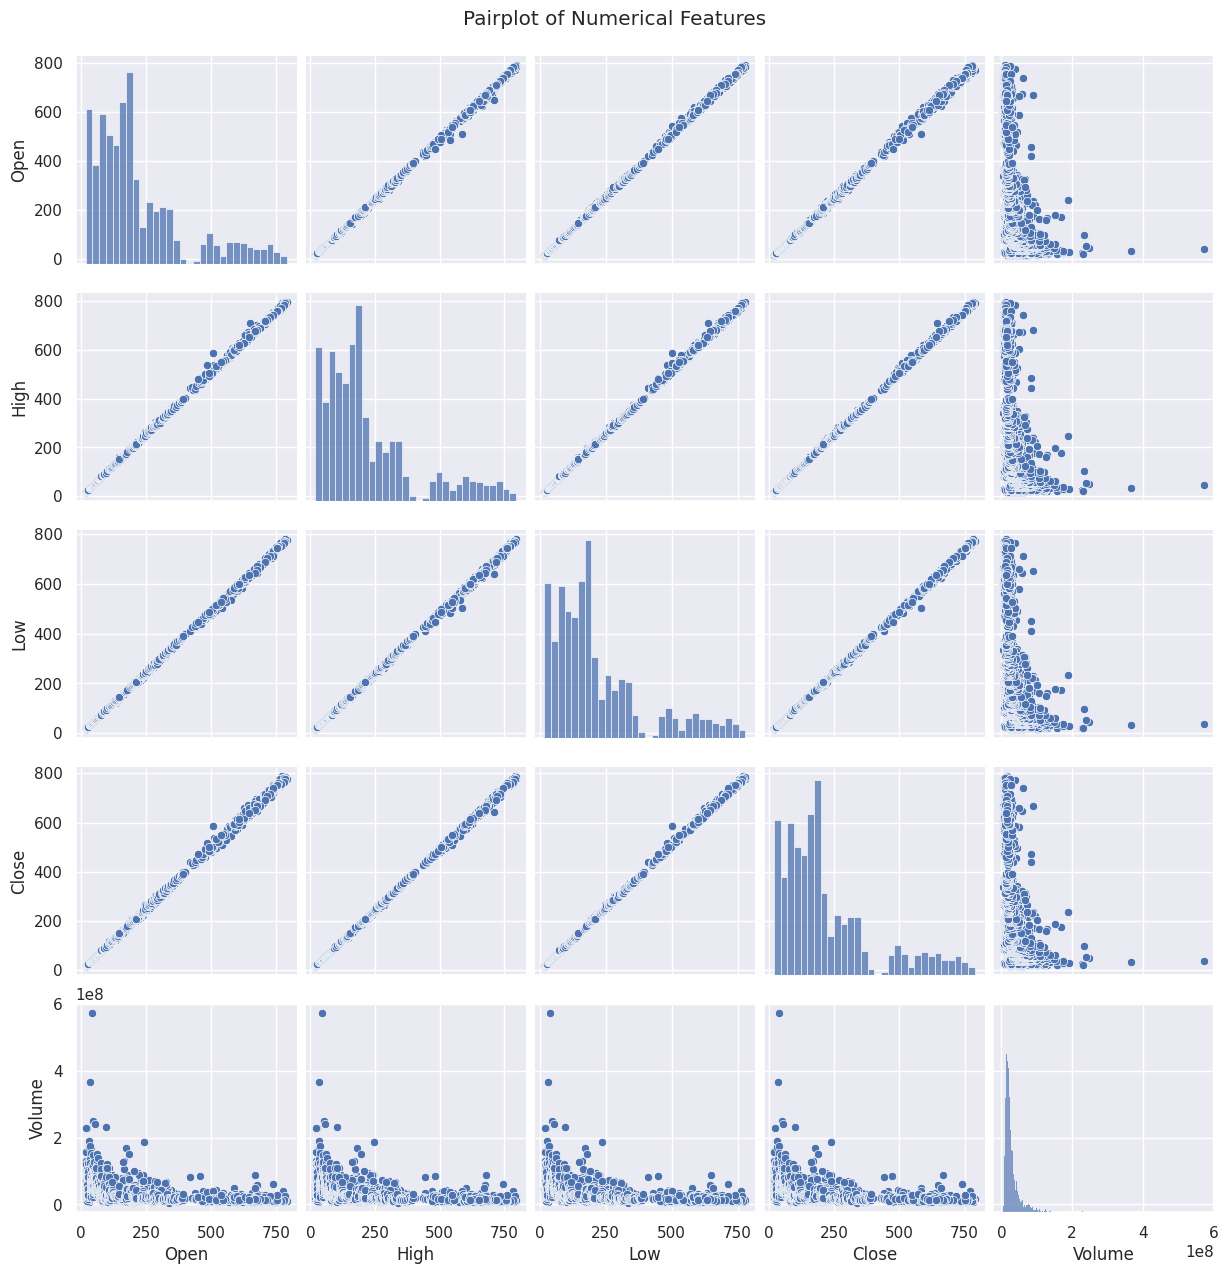

In [15]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

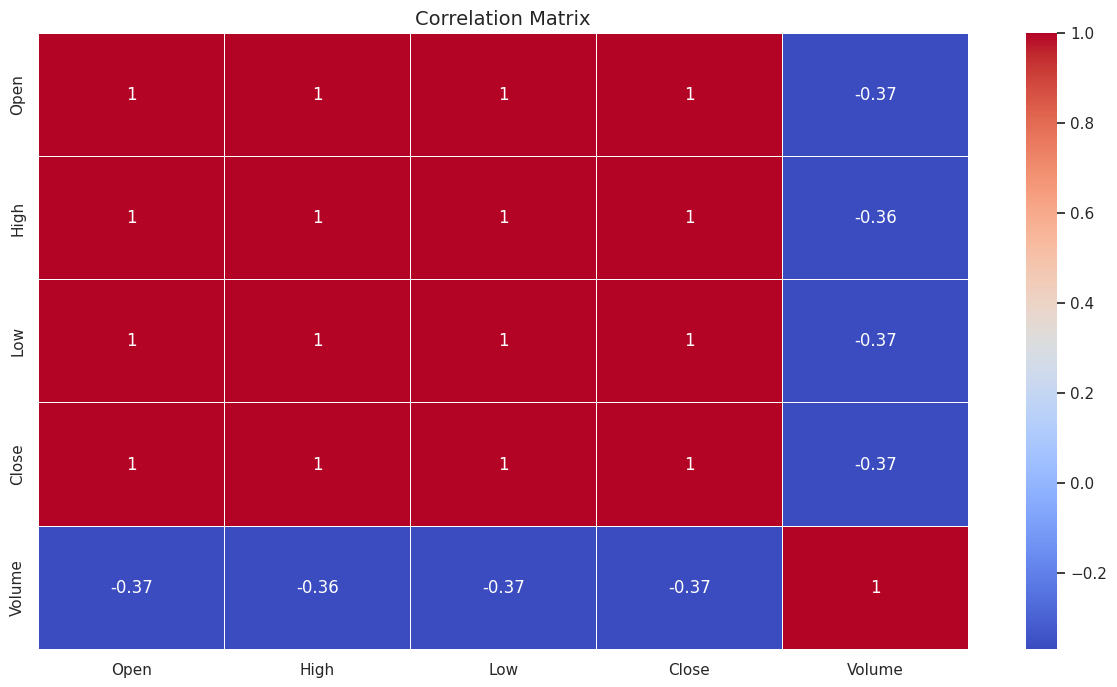

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

In [20]:
# --- 1. CONVERTING DATES ---
print("--- 1. CONVERTING DATES ---")

if isinstance(df.index, pd.DatetimeIndex) and df.index.name == 'Date':
    print(f"✅ 'Date' column is already the DataFrame's index. Time range: {df.index.min().date()} to {df.index.max().date()}")
elif 'Date' in df.columns:
    print("Found 'Date' column in DataFrame columns.")
    df['Date'] = pd.to_datetime(df['Date'])

    # Sorting the data from oldest to newest (CRITICAL for stock data)
    df = df.sort_values(by='Date')

    # Setting the Date as the Index
    df.set_index('Date', inplace=True)
    print(f"✅ 'Date' column successfully set as index. Time range: {df.index.min().date()} to {df.index.max().date()}")
else:
    print("❌ 'Date' column not found as index or as a column in the DataFrame.")

--- 1. CONVERTING DATES ---
✅ 'Date' column is already the DataFrame's index. Time range: 2012-05-18 to 2026-02-13


In [21]:
print("--- 1. CALCULATING MOVING AVERAGES ---")
# Identify the Close price column (adjust if your column is named differently, e.g., 'Adj Close')
close_col = [c for c in df.columns if 'close' in c.lower()][0]

# 50-Day Simple Moving Average (Short-term trend)
df['SMA_50'] = df[close_col].rolling(window=50).mean()

# 200-Day Simple Moving Average (Long-term trend)
df['SMA_200'] = df[close_col].rolling(window=200).mean()

# The "Golden Cross" signal (When 50-day crosses above 200-day)
df['Golden_Cross'] = (df['SMA_50'] > df['SMA_200']).astype(int)
print("✅ Created: 50-Day MA, 200-Day MA, and Golden Cross Signal")

print("\n--- 2. CALCULATING DAILY RETURNS & VOLATILITY ---")
# Daily Percentage Return
df['Daily_Return'] = df[close_col].pct_change() * 100

# 30-Day Rolling Volatility (Risk)
df['Volatility_30'] = df['Daily_Return'].rolling(window=30).std()

print("✅ Created: Daily Returns and 30-Day Volatility")

# Drop the NaN rows created by the rolling windows
df_clean = df.dropna().copy()
print(f"Dataset shape after feature engineering: {df_clean.shape}")

--- 1. CALCULATING MOVING AVERAGES ---
✅ Created: 50-Day MA, 200-Day MA, and Golden Cross Signal

--- 2. CALCULATING DAILY RETURNS & VOLATILITY ---
✅ Created: Daily Returns and 30-Day Volatility
Dataset shape after feature engineering: (3256, 13)


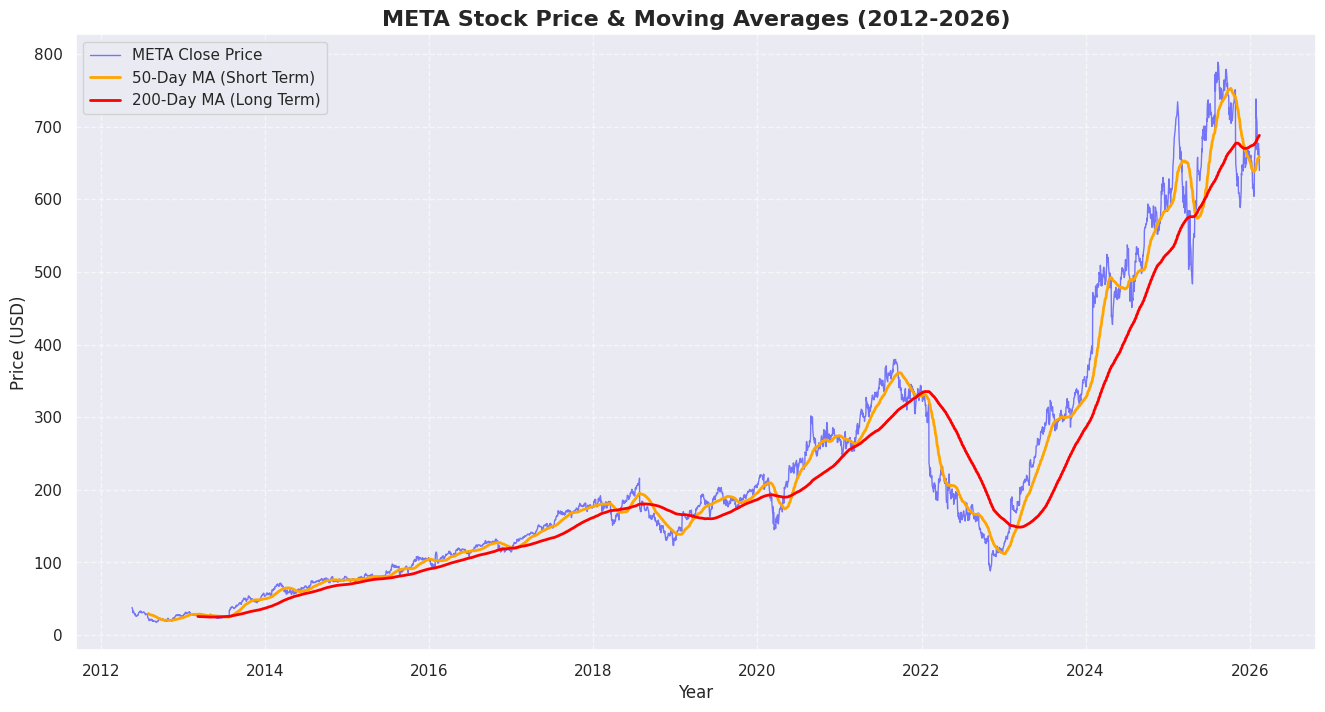

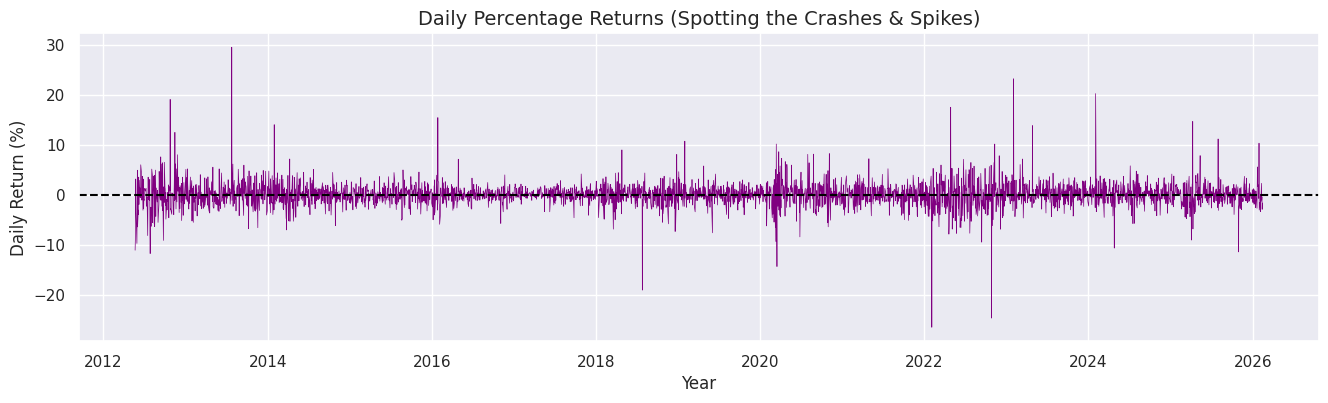

In [22]:
# 1. The Price & Trend Chart
plt.figure(figsize=(16, 8))
plt.plot(df.index, df[close_col], label='META Close Price', alpha=0.5, color='blue', linewidth=1)
plt.plot(df.index, df['SMA_50'], label='50-Day MA (Short Term)', color='orange', linewidth=2)
plt.plot(df.index, df['SMA_200'], label='200-Day MA (Long Term)', color='red', linewidth=2)

plt.title('META Stock Price & Moving Averages (2012-2026)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. The Volatility (Risk) Chart
plt.figure(figsize=(16, 4))
plt.plot(df.index, df['Daily_Return'], color='purple', linewidth=0.5)
plt.axhline(0, color='black', linestyle='--')
plt.title('Daily Percentage Returns (Spotting the Crashes & Spikes)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Daily Return (%)')
plt.show()

# Advance Financial Statistis

--- 1. THE STATIONARITY TEST (Augmented Dickey-Fuller) ---
ADF Test on RAW PRICE p-value: 9.5630e-01
ADF Test on RETURNS p-value: 0.0000e+00
✅ RESULT: The Daily Returns are 'Stationary'. We can safely use them for Predictive ML models!

--- 2. THE 'MEMORY' TEST (Autocorrelation - ACF) ---


<Figure size 1200x800 with 0 Axes>

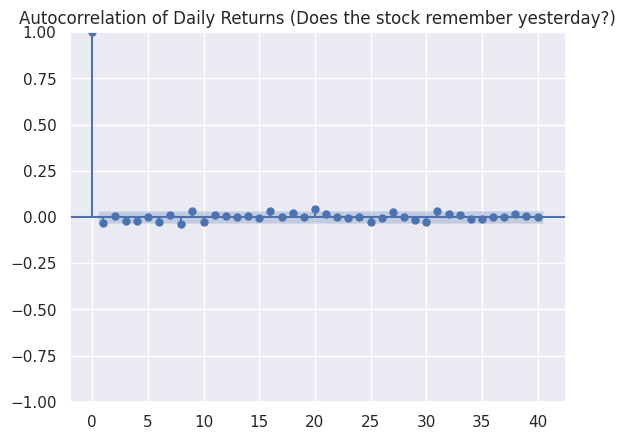


--- 3. THE 'BLACK SWAN' TEST (Normality of Returns) ---
Shapiro-Wilk Normality p-value: 7.1401e-48
✅ RESULT: Returns are NOT normally distributed. (They have 'Fat Tails').
   Meaning: Extreme crashes or massive rallies happen much more frequently than a Bell Curve predicts.


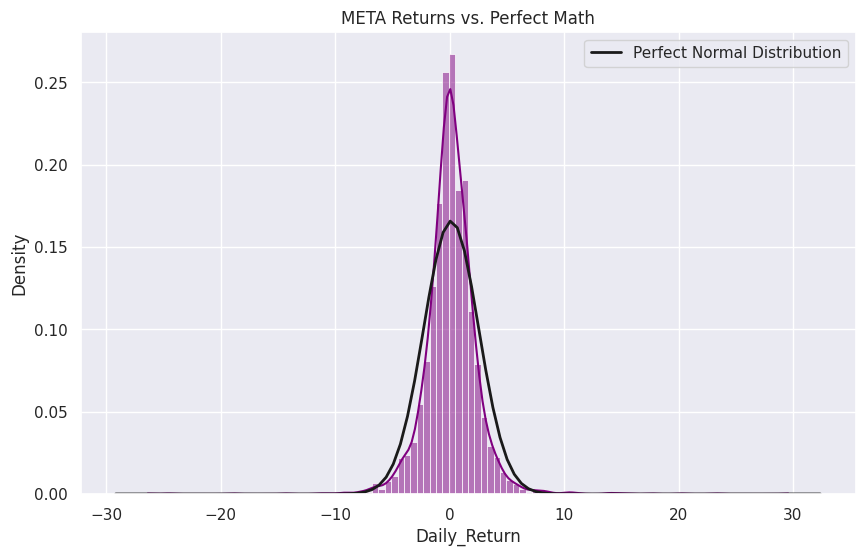


--- 4. THE RISK MEASUREMENT (Value at Risk - VaR) ---
💰 Historical 95% Value at Risk (VaR): -3.30%
   Interpretation: We are 95% confident that META will not lose more than 3.30% of its value in a single day.
   (But on the worst 5% of days... it can lose much more).


In [25]:
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

close_col = [c for c in df_clean.columns if 'close' in c.lower()][0]

print("--- 1. THE STATIONARITY TEST (Augmented Dickey-Fuller) ---")
# Question: Is the stock price purely a "random walk", or does it revert to a mean?
# A stationary time series has a constant mean and variance over time.

# Test 1: On the raw price
adf_price = adfuller(df_clean[close_col].dropna())
print(f"ADF Test on RAW PRICE p-value: {adf_price[1]:.4e}")

# Test 2: On the daily returns
adf_returns = adfuller(df_clean['Daily_Return'].dropna())
print(f"ADF Test on RETURNS p-value: {adf_returns[1]:.4e}")

if adf_returns[1] < 0.05:
    print("✅ RESULT: The Daily Returns are 'Stationary'. We can safely use them for Predictive ML models!")
else:
    print("❌ RESULT: Returns are non-stationary. Prediction will be highly unstable.")


print("\n--- 2. THE 'MEMORY' TEST (Autocorrelation - ACF) ---")
# Question: Does today's price drop mean tomorrow will also drop?
# Autocorrelation measures how much a stock's current price is correlated with its past prices (lags).

plt.figure(figsize=(12, 8))
plot_acf(df_clean['Daily_Return'].dropna(), lags=40, alpha=0.05, title='Autocorrelation of Daily Returns (Does the stock remember yesterday?)')
plt.show()


print("\n--- 3. THE 'BLACK SWAN' TEST (Normality of Returns) ---")
# Question: Are stock market crashes predictable, or do extreme events happen more than normal math expects?
# We test if the daily returns follow a perfect Bell Curve (Normal Distribution).

stat_shapiro, p_val_shapiro = stats.shapiro(df_clean['Daily_Return'].dropna())
print(f"Shapiro-Wilk Normality p-value: {p_val_shapiro:.4e}")

if p_val_shapiro < 0.05:
    print("✅ RESULT: Returns are NOT normally distributed. (They have 'Fat Tails').")
    print("   Meaning: Extreme crashes or massive rallies happen much more frequently than a Bell Curve predicts.")

# Visualizing the "Fat Tails"
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Daily_Return'].dropna(), bins=100, kde=True, color='purple', stat="density")
mu, std = df_clean['Daily_Return'].mean(), df_clean['Daily_Return'].std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label='Perfect Normal Distribution')
plt.title('META Returns vs. Perfect Math')
plt.legend()
plt.show()


print("\n--- 4. THE RISK MEASUREMENT (Value at Risk - VaR) ---")
# Question: If I invest today, what is the maximum I should expect to lose on a really bad day?
# We calculate the 95% Confidence Interval for historical losses.

# The 5th percentile of daily returns
var_95 = np.percentile(df_clean['Daily_Return'].dropna(), 5)

print(f"💰 Historical 95% Value at Risk (VaR): {var_95:.2f}%")
print(f"   Interpretation: We are 95% confident that META will not lose more than {abs(var_95):.2f}% of its value in a single day.")
print(f"   (But on the worst 5% of days... it can lose much more).")

# Feature Engineering | Financial Year

In [27]:
# The DataFrame is already indexed by 'Date' from a previous step (cell hgmlXb_3T-BD).
# The 'close_col' variable is also available from a previous cell (MJekRTEST-hF).
# Therefore, the initial block for indexing and identifying date_col can be removed.

if 'close_col' not in locals() and 'close_col' not in globals():
    close_col = [c for c in df.columns if 'close' in c.lower()][0]

print(f"✅ Data is already indexed by Date. Using '{close_col}' for calculations.")

print("\n--- 2. TREND INDICATORS (Moving Averages) ---")
# Simple Moving Averages (Smooths out daily noise to see the real trend)
df['SMA_10'] = df[close_col].rolling(window=10).mean()
df['SMA_50'] = df[close_col].rolling(window=50).mean()

# Exponential Moving Average (Reacts faster to recent price changes)
df['EMA_20'] = df[close_col].ewm(span=20, adjust=False).mean()
print("✅ Created: SMA_10, SMA_50, EMA_20")


print("\n--- 3. MOMENTUM INDICATORS (RSI & MACD) ---")
# RSI (Relative Strength Index): Measures if a stock is overbought (>70) or oversold (<30)
delta = df[close_col].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / (loss + 1e-9) # Added tiny number to prevent division by zero
df['RSI_14'] = 100 - (100 / (1 + rs))

# MACD (Moving Average Convergence Divergence): Shows changes in trend strength
ema_12 = df[close_col].ewm(span=12, adjust=False).mean()
ema_26 = df[close_col].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
print("✅ Created: RSI_14, MACD, MACD_Signal")


print("\n--- 4. VOLATILITY INDICATORS (Bollinger Bands) ---")
# Bollinger Bands: Measures how wildly the stock is swinging
df['BB_Middle'] = df[close_col].rolling(window=20).mean()
df['BB_Std'] = df[close_col].rolling(window=20).std()
df['BB_Upper'] = df['BB_Middle'] + (df['BB_Std'] * 2)
df['BB_Lower'] = df['BB_Middle'] - (df['BB_Std'] * 2)
print("✅ Created: Bollinger Bands (Upper, Middle, Lower)")


print("\n--- 5. CREATING THE 'TARGET' (For Machine Learning) ---")
# If we want to predict TOMORROW'S movement, we must shift the data backwards.
# 1 = Price goes UP tomorrow, 0 = Price goes DOWN tomorrow
df['Future_Return'] = df[close_col].shift(-1) - df[close_col]
df['Target_Direction'] = (df['Future_Return'] > 0).astype(int)

# Drop rows with NaN values created by rolling windows and shifting
df_ml = df.dropna().copy()
print("✅ Created: Target_Direction (1=Up, 0=Down)")
print(f"\nFinal Dataset Shape ready for ML: {df_ml.shape}")

✅ Data is already indexed by Date. Using 'Close' for calculations.

--- 2. TREND INDICATORS (Moving Averages) ---
✅ Created: SMA_10, SMA_50, EMA_20

--- 3. MOMENTUM INDICATORS (RSI & MACD) ---
✅ Created: RSI_14, MACD, MACD_Signal

--- 4. VOLATILITY INDICATORS (Bollinger Bands) ---
✅ Created: Bollinger Bands (Upper, Middle, Lower)

--- 5. CREATING THE 'TARGET' (For Machine Learning) ---
✅ Created: Target_Direction (1=Up, 0=Down)

Final Dataset Shape ready for ML: (3255, 24)


--- 1. THE CHRONOLOGICAL SPLIT ---
✅ Time Split Successful!
   Training on past data: 2013-03-07 to 2023-07-11
   Testing on future data: 2023-07-12 to 2026-02-12

--- 2. TRAINING THE TRADING BOT ---
✅ Random Forest Model Trained.

--- 3. BOT PERFORMANCE (DID IT BEAT A COIN FLIP?) ---
🎯 Model Accuracy: 48.23%

📊 Detailed Report:
              precision    recall  f1-score   support

Down Day (0)       0.48      0.91      0.63       312
  Up Day (1)       0.52      0.09      0.15       339

    accuracy                           0.48       651
   macro avg       0.50      0.50      0.39       651
weighted avg       0.50      0.48      0.38       651



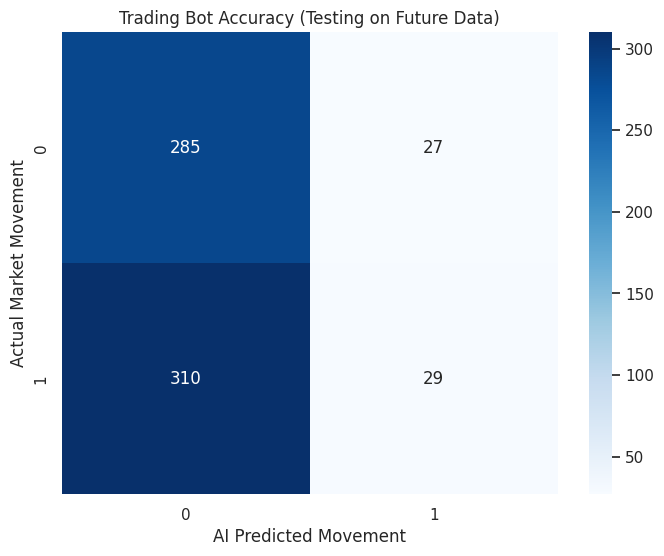


--- 4. THE ALPHA (FEATURE IMPORTANCE) ---


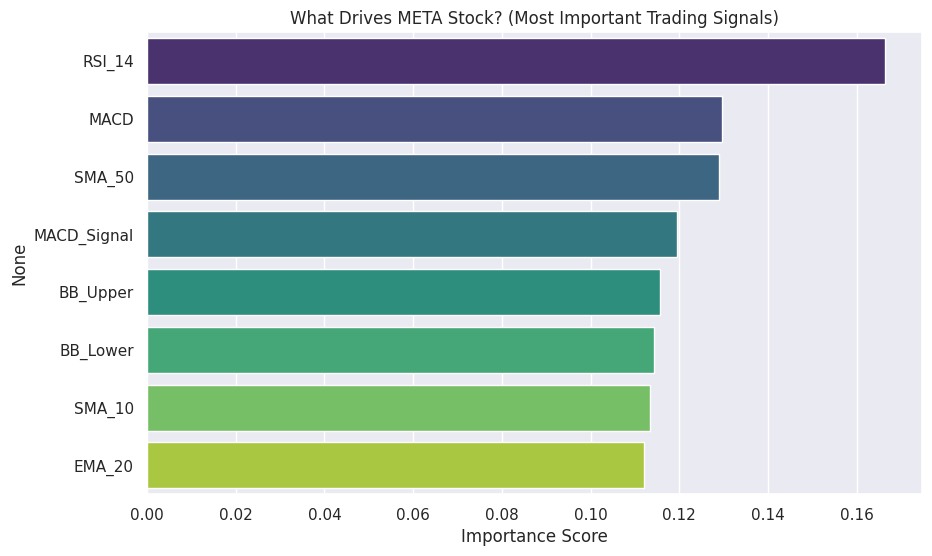

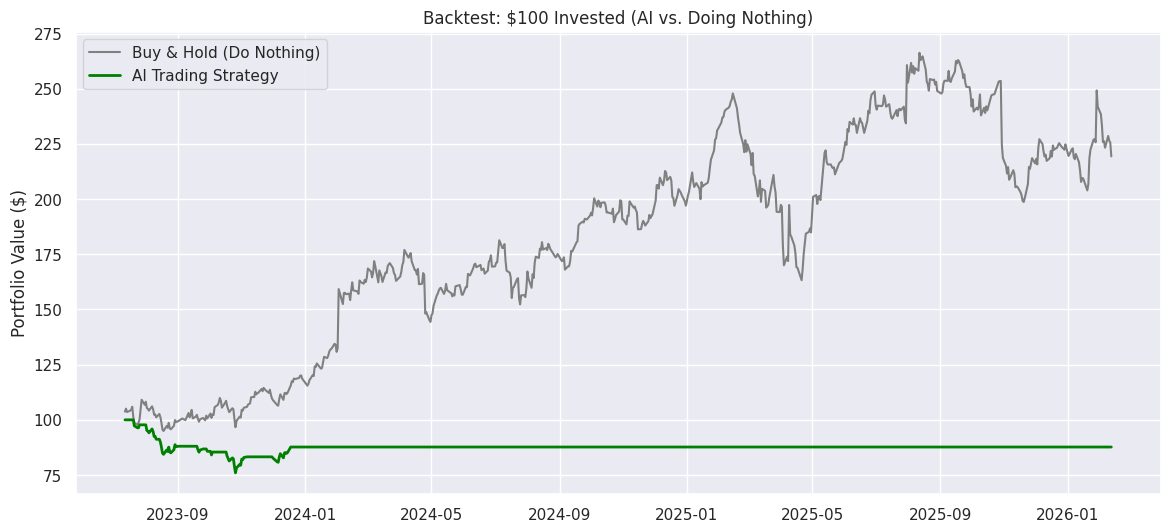

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("--- 1. THE CHRONOLOGICAL SPLIT ---")
# We use df_ml from the Feature Engineering step
features = ['SMA_10', 'SMA_50', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower']
target = 'Target_Direction'

X = df_ml[features]
y = df_ml[target]

# We must split by time! (First 80% is history, Last 20% is the future test)
split_index = int(len(df_ml) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"✅ Time Split Successful!")
print(f"   Training on past data: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"   Testing on future data: {X_test.index.min().date()} to {X_test.index.max().date()}")


print("\n--- 2. TRAINING THE TRADING BOT ---")
# We restrict the depth of the trees so the AI doesn't memorize the past (overfitting)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
print("✅ Random Forest Model Trained.")


print("\n--- 3. BOT PERFORMANCE (DID IT BEAT A COIN FLIP?) ---")
y_pred = rf_model.predict(X_test)

# In the stock market, predicting exactly 50% is a coin flip.
# Anything consistently above 53% is highly profitable on Wall Street.
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy: {accuracy * 100:.2f}%")

print("\n📊 Detailed Report:")
print(classification_report(y_test, y_pred, target_names=['Down Day (0)', 'Up Day (1)']))

# Confusion Matrix Visual
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Trading Bot Accuracy (Testing on Future Data)')
plt.ylabel('Actual Market Movement')
plt.xlabel('AI Predicted Movement')
plt.show()


print("\n--- 4. THE ALPHA (FEATURE IMPORTANCE) ---")
# Which technical indicator actually moves the needle for META?
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('What Drives META Stock? (Most Important Trading Signals)')
plt.xlabel('Importance Score')
plt.show()

# 5. SIMULATED STRATEGY BACKTEST (The ultimate test)
df_test = df_ml.iloc[split_index:].copy()
df_test['AI_Prediction'] = y_pred

# If AI says 1 (Up), we hold the stock and get the return. If 0 (Down), we sell and get 0 return.
df_test['Strategy_Return'] = df_test['Daily_Return'] * df_test['AI_Prediction']

# Calculate cumulative growth of $100
df_test['Buy_and_Hold_Growth'] = (1 + (df_test['Daily_Return'] / 100)).cumprod() * 100
df_test['AI_Strategy_Growth'] = (1 + (df_test['Strategy_Return'] / 100)).cumprod() * 100

plt.figure(figsize=(14, 6))
plt.plot(df_test.index, df_test['Buy_and_Hold_Growth'], label='Buy & Hold (Do Nothing)', color='gray')
plt.plot(df_test.index, df_test['AI_Strategy_Growth'], label='AI Trading Strategy', color='green', linewidth=2)
plt.title('Backtest: $100 Invested (AI vs. Doing Nothing)')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.show()

# Thank You